In [154]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

**Загрузка данных**

In [155]:
data = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

In [156]:

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

target_col = 'Churn'

**Первичный анализ данных**

In [157]:
data_copy = data.copy()
data_copy.sample(10)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1160,69,99.45,7007.6,Male,0,Yes,Yes,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),1
4988,47,98.75,4533.7,Female,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,1
1574,28,54.30,1546.3,Female,0,No,No,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,0
72,20,82.40,1592.35,Female,0,Yes,No,Yes,Yes,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Electronic check,1
1763,12,80.45,950.2,Male,1,Yes,No,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,1
5148,71,23.95,1756.2,Male,1,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),0
247,66,25.30,1673.8,Male,0,No,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),0
2333,49,98.35,4889.2,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,0
2353,24,20.15,456.85,Female,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
2766,24,84.85,2048.8,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,No,Month-to-month,Yes,Bank transfer (automatic),0


**Столбец TotalSpent помечен как строковый. Вместо Nan в некотрых ячейках вписан " ".**

In [158]:
data_copy[num_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ClientPeriod     5282 non-null   int64  
 1   MonthlySpending  5282 non-null   float64
 2   TotalSpent       5282 non-null   str    
dtypes: float64(1), int64(1), str(1)
memory usage: 123.9 KB


In [159]:
data_test[num_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ClientPeriod     1761 non-null   int64  
 1   MonthlySpending  1761 non-null   float64
 2   TotalSpent       1761 non-null   str    
dtypes: float64(1), int64(1), str(1)
memory usage: 41.4 KB


**Заменим строковые значения на Nan и заменим их медианой**

In [160]:
data_copy["TotalSpent"] = pd.to_numeric(data_copy["TotalSpent"], errors='coerce')
data_copy["TotalSpent"] = data_copy["TotalSpent"].fillna(data_copy["TotalSpent"].median()) 

data_test["TotalSpent"] = pd.to_numeric(data_test["TotalSpent"], errors='coerce') 
data_test["TotalSpent"] = data_test["TotalSpent"].fillna(data_test["TotalSpent"].median()) 

In [161]:
data_copy[num_cols].isna().sum()

ClientPeriod       0
MonthlySpending    0
TotalSpent         0
dtype: int64

In [162]:
data_test[num_cols].isna().sum()

ClientPeriod       0
MonthlySpending    0
TotalSpent         0
dtype: int64

**Проверим категориальные столбцы на наличие пропусков:**

In [163]:
data_copy_cat = data[cat_cols]
data_copy_cat.isna().sum()

Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
dtype: int64

In [164]:
data_test_copy_cat = data_test[cat_cols]
data_test_copy_cat.isna().sum()

Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
dtype: int64

**Построим графики распределения численных данных.**

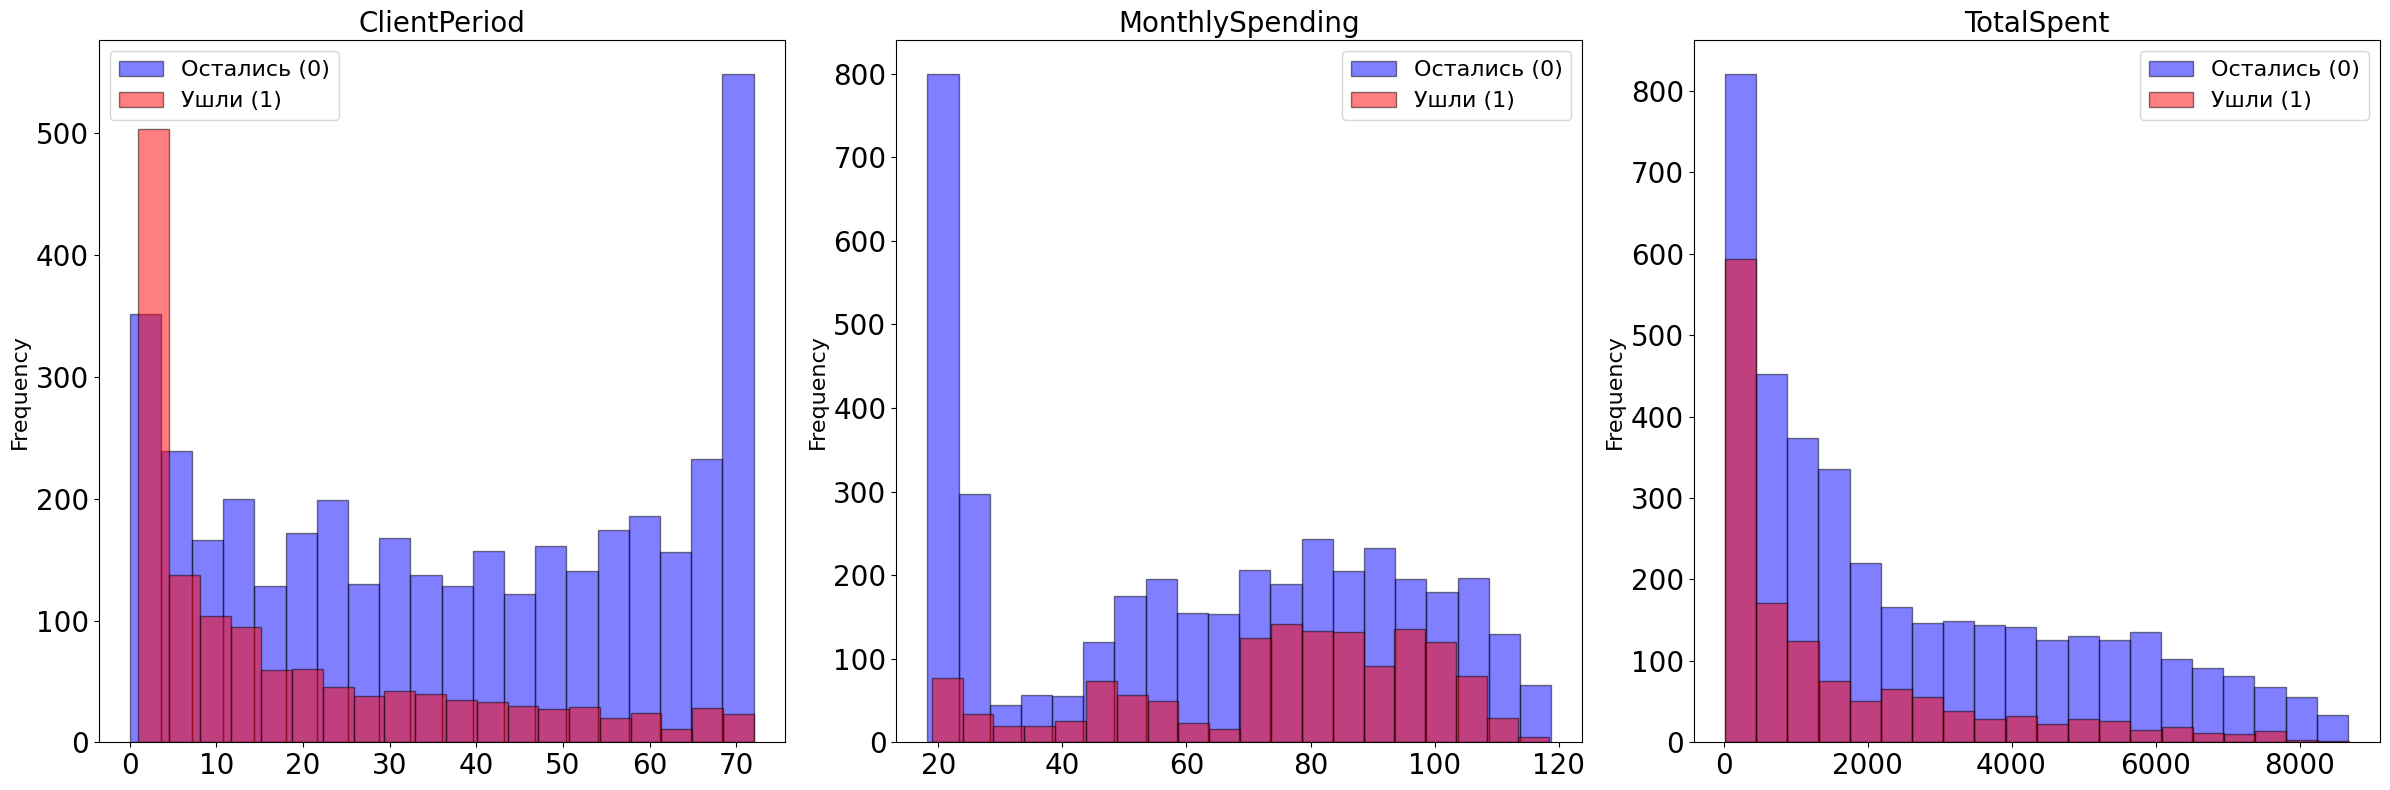

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes_flat = axes.flatten()

target_col = 'Churn' 

for column, ax in zip(num_cols, axes_flat):
    data_copy[data_copy[target_col] == 0][column].plot.hist(
        ax=ax, bins=20, alpha=0.5, color="blue", edgecolor="black", label="Остались (0)"
    )
    
    data_copy[data_copy[target_col] == 1][column].plot.hist(
        ax=ax, bins=20, alpha=0.5, color="red", edgecolor="black", label="Ушли (1)"
    )
    
    ax.set_title(f'{column}', fontsize=20)
    ax.set_ylabel("Frequency", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    ax.legend(fontsize=16) 

plt.tight_layout()
plt.show()

**Какие выводы можно сделать исходя из этих графиков?**


**`ClientPeriod`:**
* Подавляющее большинство ушедших клиентов покидают компанию в самые первые месяцы (пик от 0 до 5 месяцев). Если клиент переживает этот начальный период, вероятность его ухода резко снижается.
*  Клиенты, которые пользуются услугами долго (особенно те, кто дошел до отметки 70+), практически не уходят.
* Скорее всего, проблема кроется в онбординге (процессе адаптации новых пользователей), первых впечатлениях от сервиса или в том, что ожидания от рекламы не совпадают с реальностью. Именно в первые месяцы нужно направлять максимум усилий на удержание. 


**`MonthlySpending`**:
* Огромный синий пик на минимальных значениях (около 20) показывает, что клиенты с самыми дешевыми тарифами супер-лояльны. Они почти не уходят (красного цвета там минимум). Скорее всего, это базовая услуга, которая работает стабильно, и людей устраивает цена.
* А вот в зоне высоких трат (от 70 до 110) доля оттока (красного цвета) пугающе высока. Она визуально сопоставима с долей оставшихся, а местами даже доминирует.
* Люди, покупающие дорогие пакеты услуг, сильно разочаровываются. Возможно, качество премиальных услуг не соответствует их высокой цене, либо конкуренты предлагают аналогичные пакеты выгоднее.


**`TotalSpent`**:
* График TotalSpent логично вытекает из первых двух. Ушедшие клиенты (красные) сконцентрированы в зоне низких общих трат. Почему? Потому что они уходят в первые же месяцы (**`ClientPeriod`** низкий). Даже если их ежемесячный чек был высоким (**`MonthlySpending`**), они просто не успели принести компании много денег в сумме.
* Оставшиеся клиенты формируют длинный «хвост» вправо - это те самые лояльные пользователи, которые годами платят понемногу или средними чеками, формируя основную кассу.

Как видно из правого графика, данные имеют экспоненциальную зависимость. Применим логарифм, чтобы получить симметричные данные, иначе линейные модели могут выдать более плохой результат.

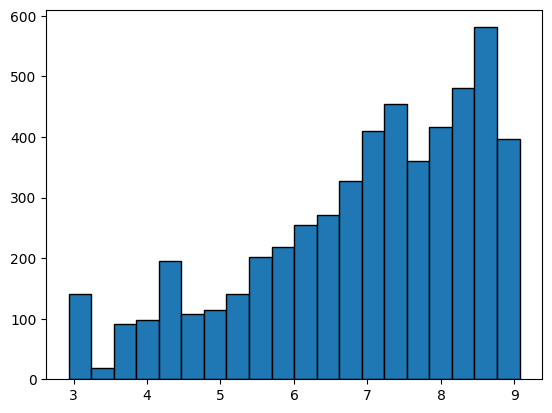

In [ ]:

plt.hist(np.log(data_copy["TotalSpent"]), edgecolor="black", bins=20)
plt.show()

In [184]:
data_copy["TotalSpent"] = np.log(data_copy["TotalSpent"])
data_test["TotalSpent"] = np.log(data_test["TotalSpent"])

**Построим корреляционную матрицу численных признаков и целевой переменной `Churn`**.

<Axes: >

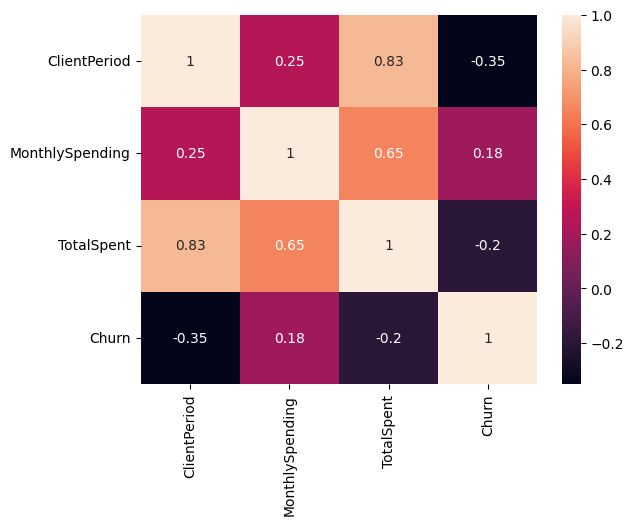

In [167]:
nums = num_cols + ["Churn"]
data_corr = data_copy[nums].corr()
sns.heatmap(data_corr, annot=True)

## Влияние признаков на отток (Target: Churn)

**`ClientPeriod` и `Churn` (-0.35: умеренная обратная зависимость)**
* **Связь с гистограммой:** Огромный пик ушедших находился слева (новые клиенты), а пик оставшихся - справа («старички»).
* **Вывод:** Чем дольше клиент с компанией, тем ниже вероятность оттока. 

**`MonthlySpending` и `Churn` (0.18: слабая прямая зависимость)**
* **Связь с гистограммой:** Дешевые тарифы удерживают клиентов лучше всего, а в зоне дорогих тарифов доля оттока резко возрастает.
* **Вывод:** Чем выше ежемесячный платеж, тем выше вероятность ухода. Зависимость не строго линейная, но тренд на уход «дорогих» клиентов очевиден.

**`TotalSpent` и `Churn` (-0.20: слабая обратная зависимость)**
* **Связь с гистограммой:** Ушедшие клиенты формировали высокий пик около нуля, уходя быстро и не успевая много заплатить.
* **Вывод:** Чем больше общая сумма трат, тем ниже вероятность оттока. По сути, этот признак просто зеркалит поведение `ClientPeriod`.

In [169]:
data_copy[cat_cols].nunique()

Sex                         2
IsSeniorCitizen             2
HasPartner                  2
HasChild                    2
HasPhoneService             2
HasMultiplePhoneNumbers     3
HasInternetService          3
HasOnlineSecurityService    3
HasOnlineBackup             3
HasDeviceProtection         3
HasTechSupportAccess        3
HasOnlineTV                 3
HasMovieSubscription        3
HasContractPhone            3
IsBillingPaperless          2
PaymentMethod               4
dtype: int64

**Можно закодировать с помощью `OneHotEncoding` стобцы, где количество уникальных элементов $\geq$ 3 и `OrdinalEncoding`, где количество символов $\le$ 2.**

In [170]:
binary_cols = []
nominal_cols = []

for col in cat_cols:
    if data[col].nunique() == 2:
        binary_cols.append(col)
    else:
        nominal_cols.append(col)
binary_cols, nominal_cols

(['Sex',
  'IsSeniorCitizen',
  'HasPartner',
  'HasChild',
  'HasPhoneService',
  'IsBillingPaperless'],
 ['HasMultiplePhoneNumbers',
  'HasInternetService',
  'HasOnlineSecurityService',
  'HasOnlineBackup',
  'HasDeviceProtection',
  'HasTechSupportAccess',
  'HasOnlineTV',
  'HasMovieSubscription',
  'HasContractPhone',
  'PaymentMethod'])

## Построим Pipeline для обработки данных "в один клик"
#### 1. Базовая обработка числовых признаков `numeric_preprocessor`

* **`imputation_mean`:** Если в данных есть пропуски (`NaN`), этот шаг заполняет их средним значением по столбцу. 
* **`scaler`:** Стандартизирует данные (`StandardScaler`), приводя их к нулевому среднему и единичной дисперсии. Это помогает линейным моделям и нейросетям быстрее и стабильнее обучаться.

#### 2. Спецобработка для `TotalSpent` `total_spent_pipeline`

* **`to_num`:** Функция `safe_to_numeric` пытается превратить текст в числа. Если в столбце затесались пробелы, параметр `errors='coerce'` превратит их в `NaN`.
* **`impute`:** Теперь, когда скрытые пропуски стали явными `NaN`, мы заполняем их средним значением.
* **`log`:** Применяется логарифмирование `np.log1p` (логарифм от x+1). Это сглаживает тот самый длинный «хвост» распределения, который мы видели на графике, делая его более нормальным.
* **`scale`:** Наконец, признак масштабируется, как и остальные числа.

#### 3. Главный распределитель `preprocessor` / `ColumnTransformer`

* **`spent_special`:** Отправляет колонку `TotalSpent` в ее сложный персональный конвейер.
* **`num`:** Отправляет `ClientPeriod` и `MonthlySpending` в базовый числовой конвейер.
* **`nominal`:** Берет номинальные категориальные признаки (где нет порядка, например, способы оплаты) и применяет `OneHotEncoder` - превращает каждую категорию в отдельный столбец с нулями и единицами.
* **`binary`:** Берет бинарные признаки (где только два значения, например, наличие телефона Да/Нет) и кодирует их через `OrdinalEncoder` в один столбец с 0 и 1.
* **`remainder='passthrough'`:** Указывает, что если в датасете остались какие-то колонки, которые не попали ни в один из списков, их нужно пропустить дальше без изменений

**Итог:** Теперь достаточно написать `X_train_processed = preprocessor.fit_transform(X_train)`, и все эти сложные преобразования выполнятся автоматически в правильном порядке.

In [171]:
numeric_preprocessor = Pipeline( 
    steps=[
        ( "imputation_mean" , SimpleImputer(missing_values=np.nan, strategy="mean")), 
        ( "scaler" , StandardScaler()), 
    ] 
)

def safe_to_numeric(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

# Обработчик для столбца "TotalSpent"
total_spent_pipeline = Pipeline(steps=[
    ('to_num', FunctionTransformer(safe_to_numeric, validate=False, feature_names_out='one-to-one')), # Избавление от пробелов
    ('impute', SimpleImputer(strategy='mean')),      
    ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')), # Логарифмирование        
    ('scale', StandardScaler())                      
])
num_cols = [
    'ClientPeriod',
    'MonthlySpending'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('spent_special', total_spent_pipeline, ['TotalSpent']),
        ('num', numeric_preprocessor, num_cols),
        ('nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('binary', OrdinalEncoder(), binary_cols)
    ],
    remainder='passthrough' 
)


In [172]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

**Разделяем данные на обучающую выборку и тестовую**

In [173]:
data_copy = data.copy() # Пересоздаем данные, чтобы убедиться в корректной работе pipeline
X, y = data_copy.drop(columns=["Churn"]), data_copy["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 


In [174]:
X_train = preprocessor.fit_transform(X_train)


**Проверим, как выглядят данные после применения пайплайна**

In [ ]:
new_data = pd.DataFrame(X_train, columns=preprocessor.get_feature_names_out())
new_data

,spent_special__TotalSpent,num__ClientPeriod,num__MonthlySpending,nominal__HasMultiplePhoneNumbers_No,nominal__HasMultiplePhoneNumbers_No phone service,nominal__HasMultiplePhoneNumbers_Yes,nominal__HasInternetService_DSL,nominal__HasInternetService_Fiber optic,nominal__HasInternetService_No,nominal__HasOnlineSecurityService_No,...,nominal__PaymentMethod_Bank transfer (automatic),nominal__PaymentMethod_Credit card (automatic),nominal__PaymentMethod_Electronic check,nominal__PaymentMethod_Mailed check,binary__Sex,binary__IsSeniorCitizen,binary__HasPartner,binary__HasChild,binary__HasPhoneService,binary__IsBillingPaperless
0,0.454241,-0.059488,0.294371,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,1.140168,1.079076,1.172548,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
2,1.138345,1.119739,1.137752,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
3,-0.615916,-1.076063,0.304313,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,0.376928,1.607694,-1.322798,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,0.145620,-0.750759,0.894182,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
4221,0.211887,-0.547444,0.282773,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4222,0.019130,0.713109,-1.461981,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4223,-0.291348,-0.994737,0.657240,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [176]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning) # Убираем некарсивые предупреждения

In [177]:
from sklearn.metrics import roc_auc_score

In [ ]:
lr = LogisticRegression()
param_grid = [
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['lbfgs', 'newton-cholesky'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]
CV_model = GridSearchCV(estimator=lr,
                        param_grid=param_grid,
                        cv=5,
                        scoring="roc_auc",
                        verbose=False,
                        n_jobs=-1
)
CV_model.fit(X_train, y_train)
X_test = preprocessor.transform(X_test)
predict = CV_model.predict_proba(X_test)[:, 1]
print("Best Roc Auc score: ", roc_auc_score(y_test, predict))



Roc Auc score:  0.8310276041041365


**Построим диаграмму весов модели, чтобы выделить наиболее значазие признаки**

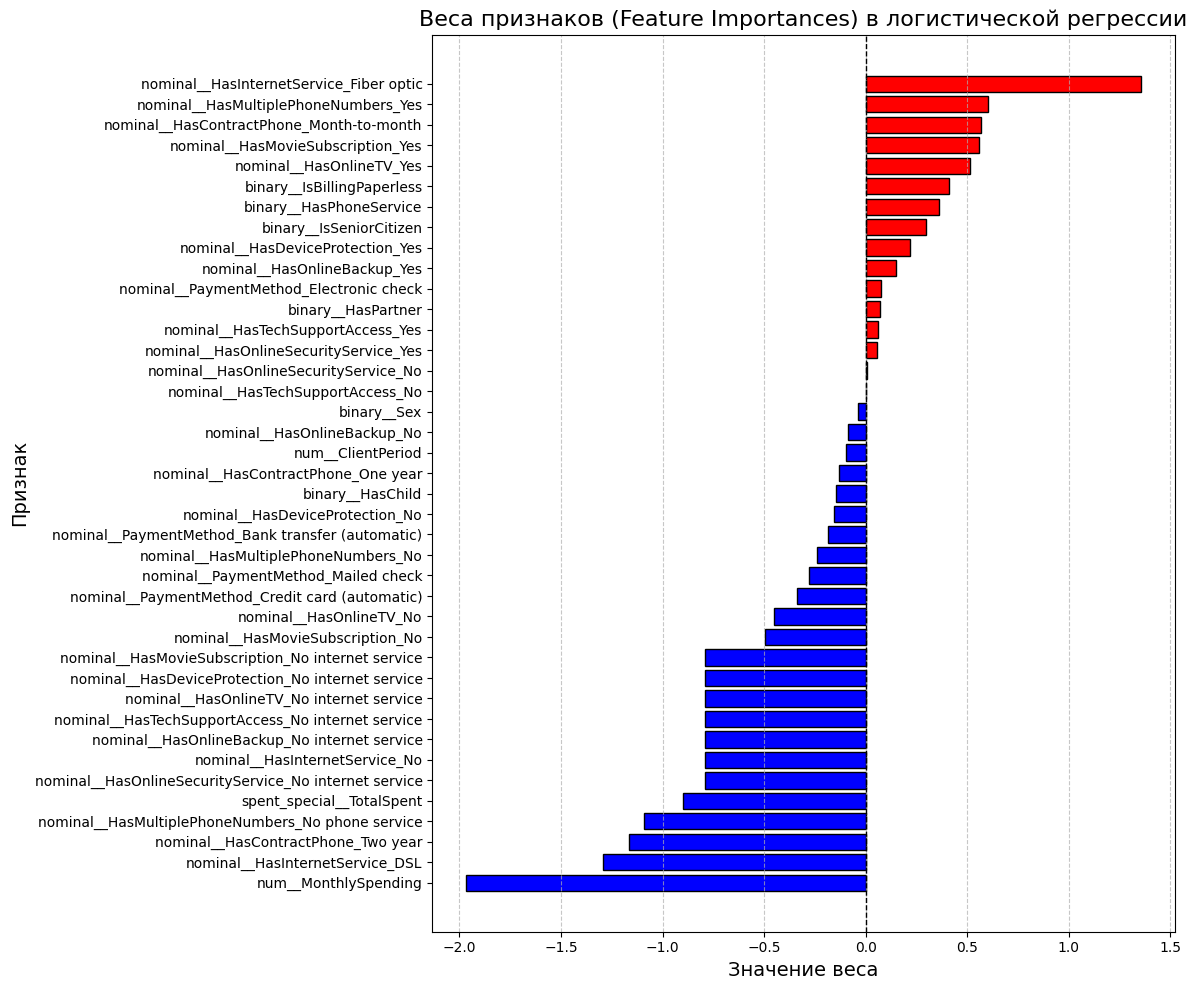

In [ ]:
best_lr = CV_model.best_estimator_

weights = best_lr.coef_[0]

feature_names = preprocessor.get_feature_names_out()

# 4. Собираем все в удобный DataFrame и сортируем по значению веса
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
})
# Сортируем от самых сильных отрицательных к самым сильным положительным
weights_df = weights_df.sort_values(by='Weight', ascending=True)

plt.figure(figsize=(12, 10)) 

colors = ['red' if w > 0 else 'blue' for w in weights_df['Weight']]

plt.barh(weights_df['Feature'], weights_df['Weight'], color=colors, edgecolor='black')

plt.title('Веса признаков (Feature Importances) в логистической регрессии', fontsize=16)
plt.xlabel('Значение веса', fontsize=14)
plt.ylabel('Признак', fontsize=14)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Итоговые выводы: Синтез разведочного анализа (EDA) и работы модели

Сопоставив графики распределения числовых признаков с весами обученной логистической регрессии, мы получили полную и логичную картину оттока клиентов. Модель математически подтвердила визуальные гипотезы и раскрыла конкретные причины поведения пользователей.

#### 1. Главная зона риска: «Разочарованные новички»
* **Визуальный инсайт:** Гистограммы показали, что основная масса ушедших - это новые клиенты (`ClientPeriod` близко к нулю) с высокими ежемесячными чеками (`MonthlySpending` > 70).
* **Подтверждение моделью:** Веса регрессии объяснили, *на что* именно тратят деньги эти люди. Абсолютными лидерами по вкладу в отток стали наличие оптоволокна (`InternetService_Fiber optic`) и отсутствие долгосрочных обязательств (`Contract_Month-to-month`). 
* **Бизнес-вывод:** Клиенты подключают дорогой скоростной интернет на пробу (без контракта), быстро разочаровываются (возможно, из-за цены, сбоев или плохой техподдержки) и уходят к конкурентам в первые же месяцы.

#### 2. Фундамент стабильности: «Лояльные консерваторы»
* **Визуальный инсайт:** На графиках мы видели огромное ядро клиентов-«ветеранов» с максимальным сроком жизни и минимальными ежемесячными тратами (пик около 20), которые практически не подвержены оттоку.
* **Подтверждение моделью:** Сильнейшие отрицательные веса (удерживающие факторы) получили признаки: контракты на 1-2 года (`Contract_Two year`), наличие только базового DSL-интернета или полное отсутствие интернета (группа признаков `No internet service`).
* **Бизнес-вывод:** Базовые, недорогие услуги связи работают отлично. Юридическая привязка в виде долгосрочного контракта является самым надежным способом удержания абонентской базы.

#### 3. Рекомендации для бизнеса
* **Аудит оптоволокна:** Необходимо срочно проверить качество услуги `Fiber optic` и её конкурентоспособность на рынке. Текущий продукт генерирует основной отток.
* **Удержание на старте:** Процесс онбординга (адаптации) в первые 3-5 месяцев требует переработки, особенно для пользователей премиум-сегмента.
* **Стимулирование контрактов:** Стоит разработать агрессивные промо-кампании по переводу клиентов с помесячной оплаты на годовые и двухгодовые контракты (например, предлагать существенную скидку за фиксацию срока).

#### 4. Технические выводы (Data Science)
* Логистическая регрессия отлично справилась с задачей интерпретации, но обнажила проблемы в подготовке данных.
* **Мультиколлинеарность:** Мы наблюдали «лесенку» из одинаковых весов для признаков `No internet service`, что является следствием прямого One-Hot Encoding без удаления первой колонки. 
* Также мы увидели компенсаторный эффект: чтобы сбалансировать огромный положительный вес оптоволокна, модель была вынуждена присвоить сильный отрицательный вес общему чеку (`MonthlySpending`), что расходится с прямой бизнес-логикой, но математически верно для линейной функции. 
* В дальнейших итерациях стоит использовать параметр `drop='first'` при кодировании категорий или опираться на градиентный бустинг (например, CatBoost), который не чувствителен к подобным артефактам данных.

In [179]:
from catboost import CatBoostClassifier


**Используем модель catboost, предварительно лишь обработав столбец `TotalSpent` путем замены пропусков медианой.**

In [180]:
data_copy = data.copy()
data_copy["TotalSpent"] = pd.to_numeric(data_copy["TotalSpent"], errors='coerce') # заменяем строковые значения на nan
data_copy["TotalSpent"] = data_copy["TotalSpent"].fillna(data_copy["TotalSpent"].median())
X, y = data_copy.drop(columns=["Churn"]), data_copy["Churn"]


In [181]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [182]:
cat = CatBoostClassifier(
    verbose=False,    
    random_state=42
)

# Сетка параметров для catboost
param_grid = {
    'iterations': [100, 200, 300],       # Количество деревьев
    'learning_rate': [0.01, 0.05, 0.1],  # Скорость обучения
    'depth': [4, 6]                   # Глубина каждого дерева
}

grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


# Передаем наши сырые, не отмасштабированные X_train
grid_cat.fit(X_train, y_train, cat_features=list(cat_cols))

print("Лучшие параметры CatBoost:", grid_cat.best_params_)
print("Лучший ROC-AUC на кросс-валидации:", grid_cat.best_score_)

# Делаем предсказание на тесте
predict_probs = grid_cat.predict_proba(X_test)[:, 1]
print("ROC-AUC на тесте:", roc_auc_score(y_test, predict_probs))

Лучшие параметры CatBoost: {'depth': 4, 'iterations': 100, 'learning_rate': 0.1}
Лучший ROC-AUC на кросс-валидации: 0.8513399194861776
ROC-AUC на тесте: 0.827790655793722


### Линейные модели vs Градиентный бустинг (CatBoost): стоила ли игра свеч?

Проведя исследование и обучив наши модели, мы пришли к очень интересному выводу, сравнив два совершенно разных подхода. 

**Путь №1: Логистическая регрессия (Долгий путь)**
Мы потратили немало времени на тщательную подготовку данных: выстраивали сложные пайплайны, аккуратно заполняли пропуски, логарифмировали `TotalSpent` для сглаживания распределения, применяли `StandardScaler` для масштабирования числовых признаков и `OneHotEncoder` для кодирования категорий. Линейные (и логистические) модели очень капризны - они требуют идеальной математической чистоты и нормализации данных, иначе алгоритм просто не сойдется или выдаст неадекватные веса. Мы проделали работу по Feature Engineering.

**Путь №2: CatBoost (Быстрый путь)**
А затем мы взяли `CatBoost`. Магия этого алгоритма в том, что ему практически не нужны наши пайплайны. Он «из коробки» умеет работать с сырыми категориальными признаками (без всякого OHE), ему абсолютно всё равно на масштаб числовых фичей (деревьям не нужен скейлер), и он сам прекрасно переваривает пропуски. По сути, мы просто передали ему исходный датафрейм, использовали `fit` и получили результат моментально.

**Итог: Время или Интерпретируемость?**
Самое показательное, что конкретно в этой задаче оттока точность обеих моделей оказалась примерно одинаковой! Наша тщательно выверенная логистическая регрессия показала достойный результат, доказав, что ручная обработка данных работает. Но `CatBoost` выдал аналогичное качество предсказаний практически без предварительной подготовки, сэкономив нам массу времени на написание кода. 

**Вывод:** Если нам критически важна абсолютная прозрачность и интерпретируемость каждого признака для бизнеса - наш долгий путь с пайплайнами и регрессией был оправдан. Но если главная цель - максимально быстро получить мощную модель с высокой точностью «здесь и сейчас», CatBoost оказывается вне конкуренции.

**Записываем результаты предсказания модели на тестовой выборке.**

In [ ]:
answer = pd.DataFrame({
    "Id": range(len(predict_probs)),
    "Churn": predict_probs
})
answer.to_csv("my_answer.csv", index=False)